In [ ]:
# CELL 1: ENVIRONMENT SETUP AND CONFIGURATION

import sys
import subprocess
import torch
import numpy as np
import random
import os
import warnings

# 1. Install Required Libraries
# -----------------------------
# We install specific versions known for stability in a production RAG pipeline.
# faiss-cpu is used here for broad compatibility; faiss-gpu can be swapped for L40S optimization if needed.
libraries = [
    "torch",
    "transformers[torch]",
    "datasets",
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "sentence-transformers",
    "faiss-cpu",
    "accelerate",
    "evaluate",
    "rouge_score",
    "bert_score",
    "bertopic",
    "tqdm"
]

print("Installing required libraries...")
# Use subprocess to run pip install
subprocess.check_call([sys.executable, "-m", "pip", "install"] + libraries, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("✅ Libraries installed successfully.")

# 2. Import Core Libraries
# ------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import set_seed

# 3. Hardware Check (GPU)
# -----------------------
print("\n" + "="*50)
print("HARDWARE CONFIGURATION")
print("="*50)

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"✅ GPU Detected: {gpu_name}")
    print(f"   Total Memory: {gpu_memory:.2f} GB")
    print(f"   CUDA Version: {torch.version.cuda}")
    # Set device to the first GPU
    torch.cuda.set_device(0)
else:
    device = torch.device("cpu")
    print("⚠️ GPU not found. Falling back to CPU. Training will be significantly slower.")

print(f"   PyTorch Device: {device}")

# 4. Reproducibility Setup
# ------------------------
def set_global_seed(seed: int = 42):
    """
    Sets the seed for reproducibility across random, numpy, and torch.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # CuDNN deterministic mode
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Transformers seed
    set_seed(seed)

    print(f"✅ Global seed set to: {seed}")

# Set the seed
SEED = 42
set_global_seed(SEED)

# 5. Version Logging
# ------------------
print("\n" + "="*50)
print("LIBRARY VERSIONS")
print("="*50)
print(f"Python:      {sys.version.split(' ')[0]}")
print(f"PyTorch:     {torch.__version__}")
print(f"Transformers:{__import__('transformers').__version__}")
print(f"Pandas:      {pd.__version__}")
print(f"Numpy:       {np.__version__}")
print(f"FAISS:       {'Available' if 'faiss' in sys.modules else 'Not Imported'}")
print("="*50)

# Suppress unnecessary warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

Installing required libraries...
✅ Libraries installed successfully.

HARDWARE CONFIGURATION
✅ GPU Detected: NVIDIA L40S
   Total Memory: 44.52 GB
   CUDA Version: 12.8
   PyTorch Device: cuda
✅ Global seed set to: 42

LIBRARY VERSIONS
Python:      3.12.11
PyTorch:     2.8.0+cu128
Transformers:5.0.0
Pandas:      2.1.4
Numpy:       1.26.4
FAISS:       Not Imported


In [ ]:
# CELL 2: DATA LOADING AND INITIAL INSPECTION (KAGGLE SOURCE)

import subprocess
import sys

# 1. Install kagglehub if not present
# ------------------------------------
try:
    import kagglehub
except ImportError:
    print("Installing kagglehub...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub[pandas-datasets]"])
    import kagglehub

from kagglehub import KaggleDatasetAdapter
import pandas as pd

print("Loading dataset from Kaggle...")

# 2. Load Dataset
# ----------------
# The dataset 'kaggle/us-consumer-finance-complaints' typically contains
# a file named 'consumer_complaints.csv'.
# We specify the file path inside the dataset.
file_path = "consumer_complaints.csv"

try:
    df = kagglehub.load_dataset(
      KaggleDatasetAdapter.PANDAS,
      "kaggle/us-consumer-finance-complaints",
      file_path,
      pandas_kwargs={"low_memory": False} # low_memory=False to handle mixed types better
    )
    print(f"✅ Dataset loaded successfully from Kaggle.")
    print(f"   Source: kaggle/us-consumer-finance-complaints")

except Exception as e:
    print(f"❌ Error loading dataset from Kaggle: {e}")
    # Stop execution if data loading fails
    raise SystemExit("Data loading failed. Please check Kaggle credentials or network access.")

# 3. Display Schema
# -----------------
print("\n" + "="*50)
print("DATASET SCHEMA")
print("="*50)
print(f"Total Records: {len(df):,}")
print(f"Total Columns: {df.shape[1]}")
print("\nColumn Names and Data Types:")
print(df.dtypes)

# 4. Memory Usage
# ---------------
print("\n" + "="*50)
print("MEMORY USAGE")
print("="*50)
memory_usage = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Total Memory Usage: {memory_usage:.2f} MB")

# 5. Missing Values Report
# ------------------------
print("\n" + "="*50)
print("MISSING VALUES REPORT")
print("="*50)
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

# 6. Sample Data Preview
# ----------------------
print("\n" + "="*50)
print("SAMPLE DATA PREVIEW (Top 3 Rows)")
print("="*50)
# Check for the narrative column (might differ in naming convention)
narrative_col = None
potential_names = ['consumer_complaint_narrative', 'consumer_complaint_narrative', 'narrative']
for name in potential_names:
    if name in df.columns:
        narrative_col = name
        break

if narrative_col:
    df['narrative_preview'] = df[narrative_col].astype(str).str.slice(0, 80) + '...'
    display_cols = ['narrative_preview', 'product', 'issue', 'company_response_to_consumer', 'timely_response', 'consumer_disputed?']
    # Ensure display columns exist
    display_cols = [c for c in display_cols if c in df.columns]
    print(df[display_cols].head(3).to_string())
else:
    print("Could not find complaint narrative column.")
    print(df.head(3))

# 7. Verify Critical Columns
# --------------------------
# Mapping expected names to actual names
print("\n" + "="*50)
print("COLUMN VALIDATION")
print("="*50)

required_cols_map = {
    'narrative': ['consumer_complaint_narrative', 'consumer_complaint_narrative'],
    'product': ['product'],
    'issue': ['issue'],
    'response': ['company_response_to_consumer', 'company_response'],
    'timely': ['timely_response', 'timely'],
    'disputed': ['consumer_disputed?', 'consumer_disputed']
}

found_cols = {}
all_present = True

for key, options in required_cols_map.items():
    found = False
    for opt in options:
        if opt in df.columns:
            found_cols[key] = opt
            print(f"✅ Found '{key}' column: {opt}")
            found = True
            break
    if not found:
        print(f"❌ MISSING required column group: {key}")
        all_present = False

if not all_present:
    print("\n⚠️ Warning: Critical columns missing. Check dataset version.")
else:
    print("\n✅ All critical columns identified.")

Loading dataset from Kaggle...


/tmp/ipykernel_37632/2313762824.py:28: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


✅ Dataset loaded successfully from Kaggle.
   Source: kaggle/us-consumer-finance-complaints

DATASET SCHEMA
Total Records: 555,957
Total Columns: 18

Column Names and Data Types:
date_received                   object
product                         object
sub_product                     object
issue                           object
sub_issue                       object
consumer_complaint_narrative    object
company_public_response         object
company                         object
state                           object
zipcode                         object
tags                            object
consumer_consent_provided       object
submitted_via                   object
date_sent_to_company            object
company_response_to_consumer    object
timely_response                 object
consumer_disputed?              object
complaint_id                     int64
dtype: object

MEMORY USAGE
Total Memory Usage: 560.76 MB

MISSING VALUES REPORT
                              Missing 

Starting Deep EDA...


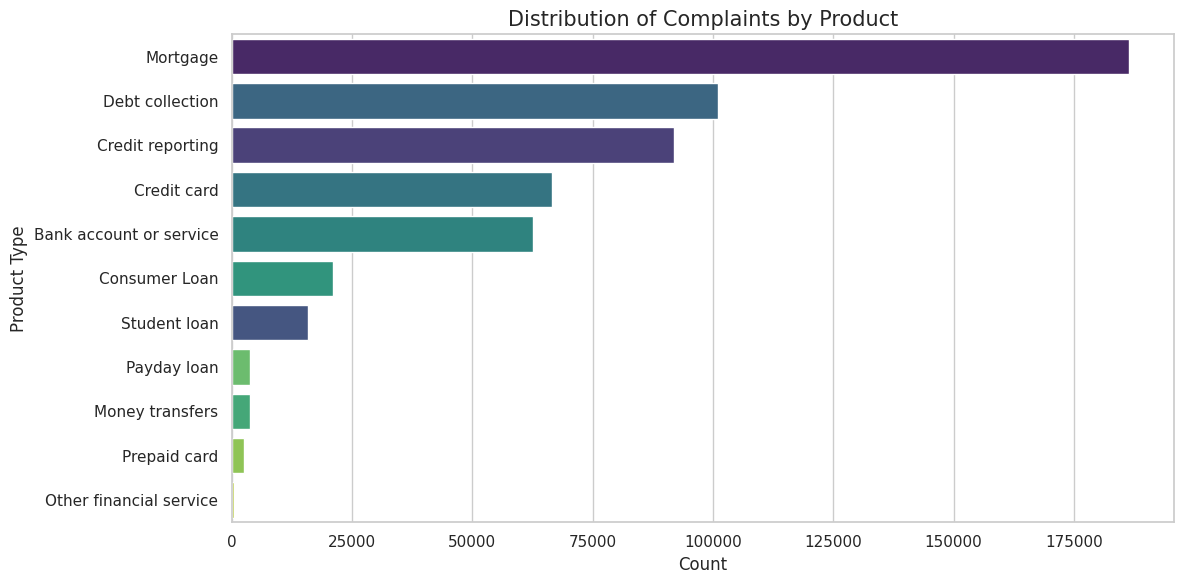


📊 Product Distribution Analysis:
product
Mortgage                   0.335413
Debt collection            0.181762
Credit reporting           0.165218
Credit card                0.119556
Bank account or service    0.112532
Name: proportion, dtype: float64


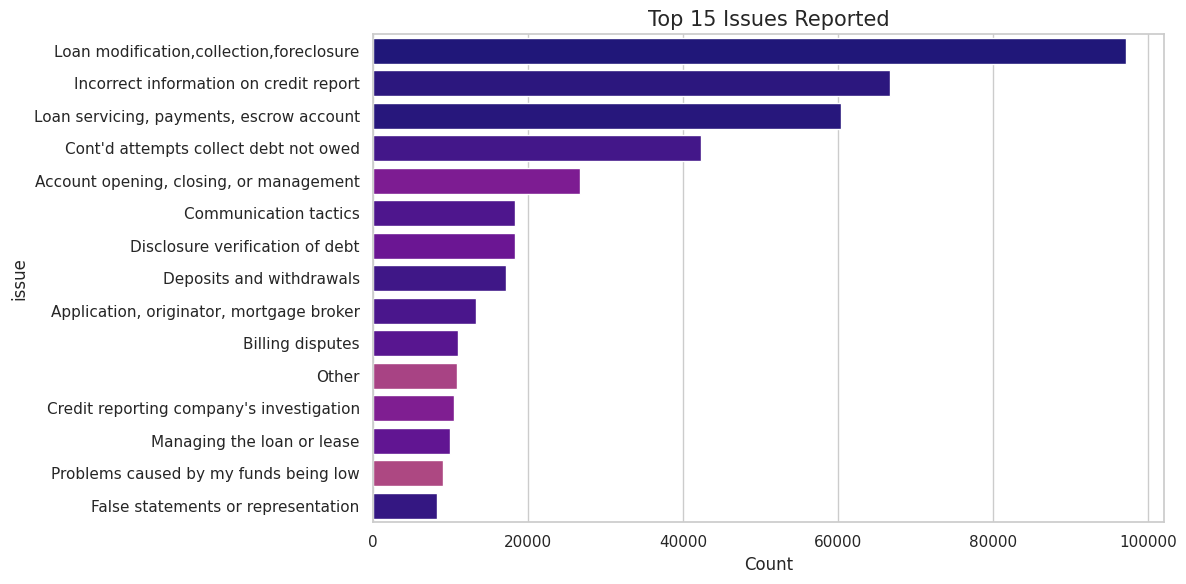

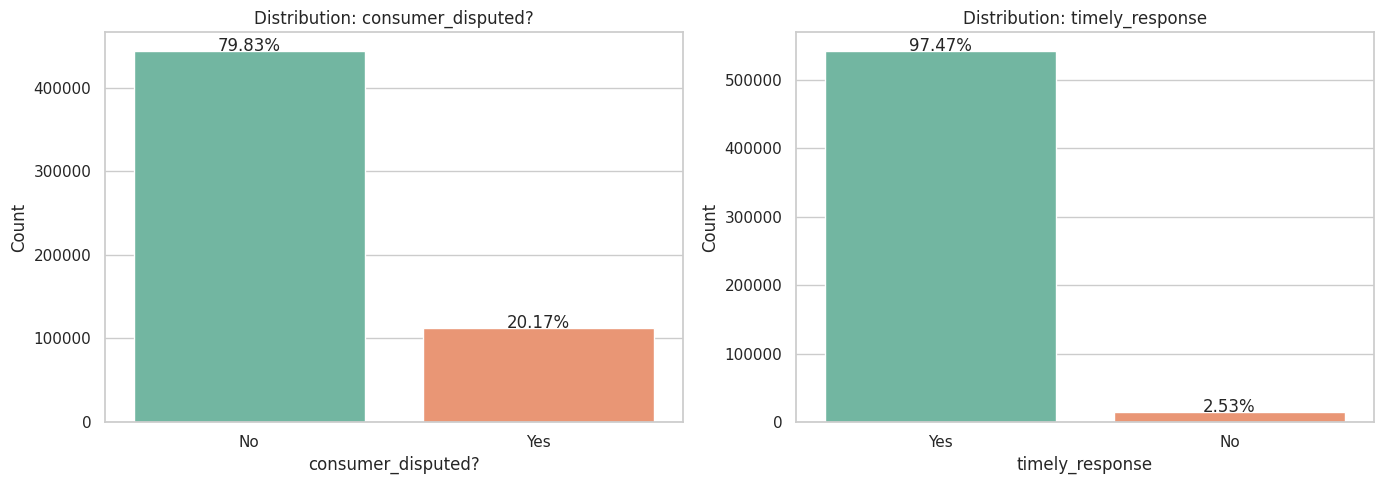


📊 Class Imbalance Ratio (Disputed): 3.96:1


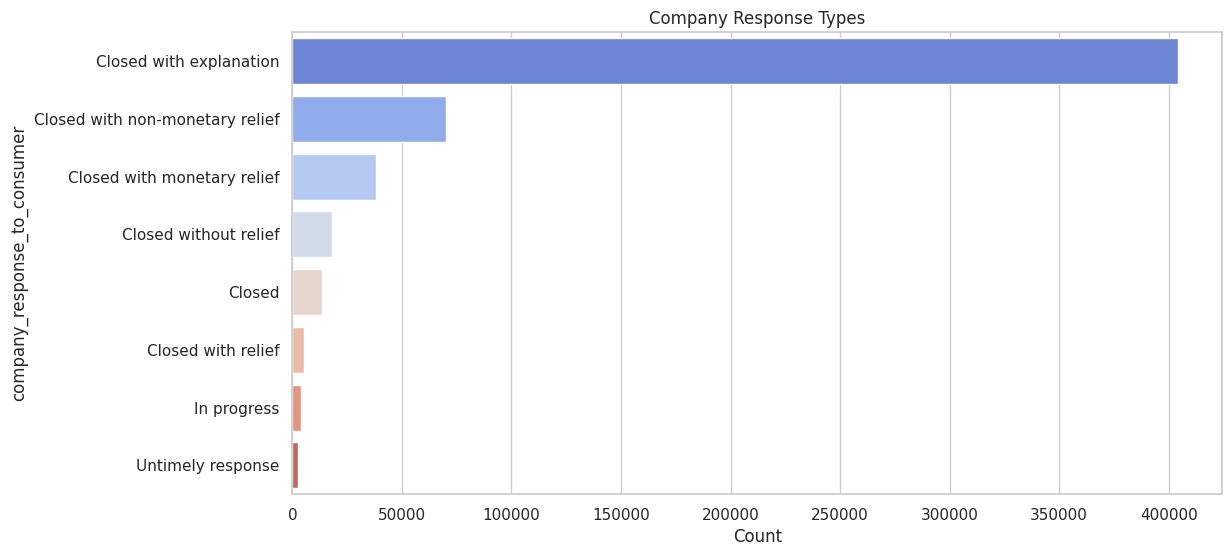

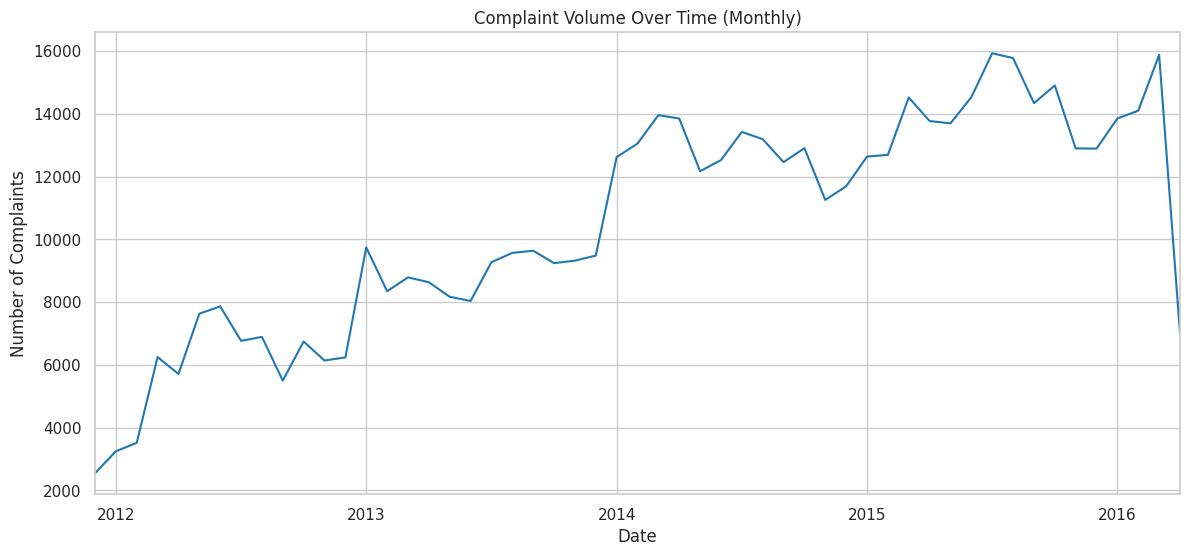

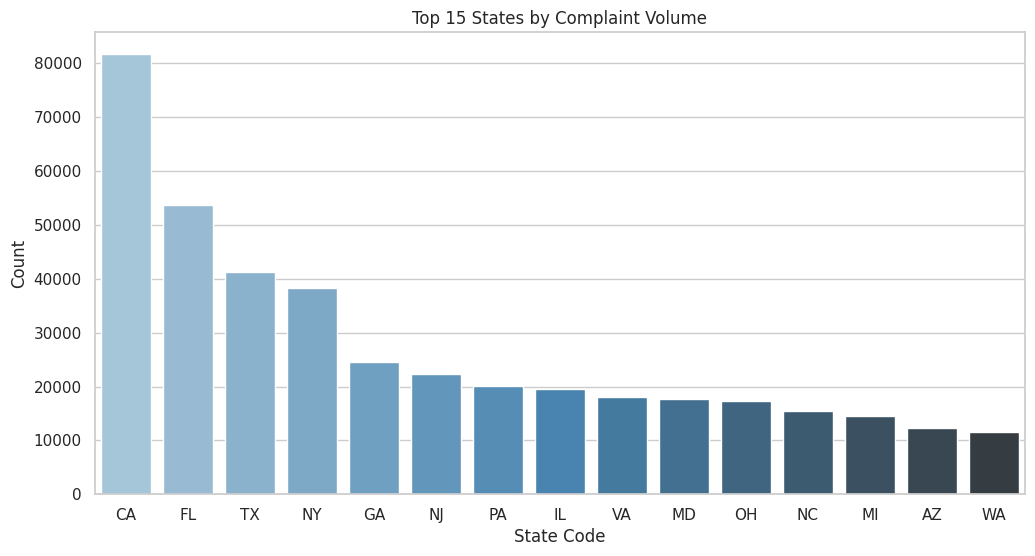

In [ ]:
# CELL 3.1: CATEGORICAL & TEMPORAL ANALYSIS

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set plot style
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Check if df exists
if 'df' not in locals():
    raise NameError("DataFrame 'df' not found. Please run the Data Loading cell.")

print("Starting Deep EDA...")

# 1. Product Distribution
# -----------------------
fig, ax = plt.subplots()
sns.countplot(data=df, y='product', order=df['product'].value_counts().index, ax=ax, hue='product', palette='viridis', legend=False)
ax.set_title('Distribution of Complaints by Product', fontsize=15)
ax.set_xlabel('Count')
ax.set_ylabel('Product Type')
plt.tight_layout()
plt.show()

print("\n📊 Product Distribution Analysis:")
print(df['product'].value_counts(normalize=True).head(5))

# 2. Issue Distribution (Top 15)
# ------------------------------
fig, ax = plt.subplots()
sns.countplot(data=df, y='issue', order=df['issue'].value_counts().iloc[:15].index, ax=ax, hue='issue', palette='plasma', legend=False)
ax.set_title('Top 15 Issues Reported', fontsize=15)
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

# 3. Class Imbalance Quantification
# ---------------------------------
targets = ['consumer_disputed?', 'timely_response']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(targets):
    if col in df.columns:
        counts = df[col].value_counts()
        sns.barplot(x=counts.index, y=counts.values, ax=axes[i], hue=counts.index, palette='Set2', legend=False)
        axes[i].set_title(f'Distribution: {col}')
        axes[i].set_ylabel('Count')

        # Add percentage labels
        total = len(df)
        for p in axes[i].patches:
            height = p.get_height()
            axes[i].text(p.get_x() + p.get_width()/2.,
                    height + 3,
                    '{:1.2f}%'.format(100 * height / total),
                    ha="center")

plt.tight_layout()
plt.show()

imbalance_ratio_disputed = df['consumer_disputed?'].value_counts().max() / df['consumer_disputed?'].value_counts().min()
print(f"\n📊 Class Imbalance Ratio (Disputed): {imbalance_ratio_disputed:.2f}:1")

# 4. Company Response Patterns
# ----------------------------
if 'company_response_to_consumer' in df.columns:
    fig, ax = plt.subplots()
    response_counts = df['company_response_to_consumer'].value_counts()
    sns.barplot(y=response_counts.index, x=response_counts.values, ax=ax, hue=response_counts.index, palette='coolwarm', legend=False)
    ax.set_title('Company Response Types')
    ax.set_xlabel('Count')
    plt.show()

# 5. Temporal Trend Analysis
# --------------------------
if 'date_received' in df.columns:
    try:
        df['date_received'] = pd.to_datetime(df['date_received'])
        complaints_over_time = df.set_index('date_received').resample('M').size()

        fig, ax = plt.subplots(figsize=(14, 6))
        complaints_over_time.plot(ax=ax, color='tab:blue')
        ax.set_title('Complaint Volume Over Time (Monthly)')
        ax.set_xlabel('Date')
        ax.set_ylabel('Number of Complaints')
        plt.show()
    except Exception as e:
        print(f"Could not parse dates: {e}")

# 6. State-level Distribution (Top 15)
# ------------------------------------
if 'state' in df.columns:
    fig, ax = plt.subplots()
    top_states = df['state'].value_counts().head(15)
    sns.barplot(x=top_states.index, y=top_states.values, ax=ax, hue=top_states.index, palette='Blues_d', legend=False)
    ax.set_title('Top 15 States by Complaint Volume')
    ax.set_xlabel('State Code')
    ax.set_ylabel('Count')
    plt.show()

Installing wordcloud...
Analyzing 66,806 non-null narratives...


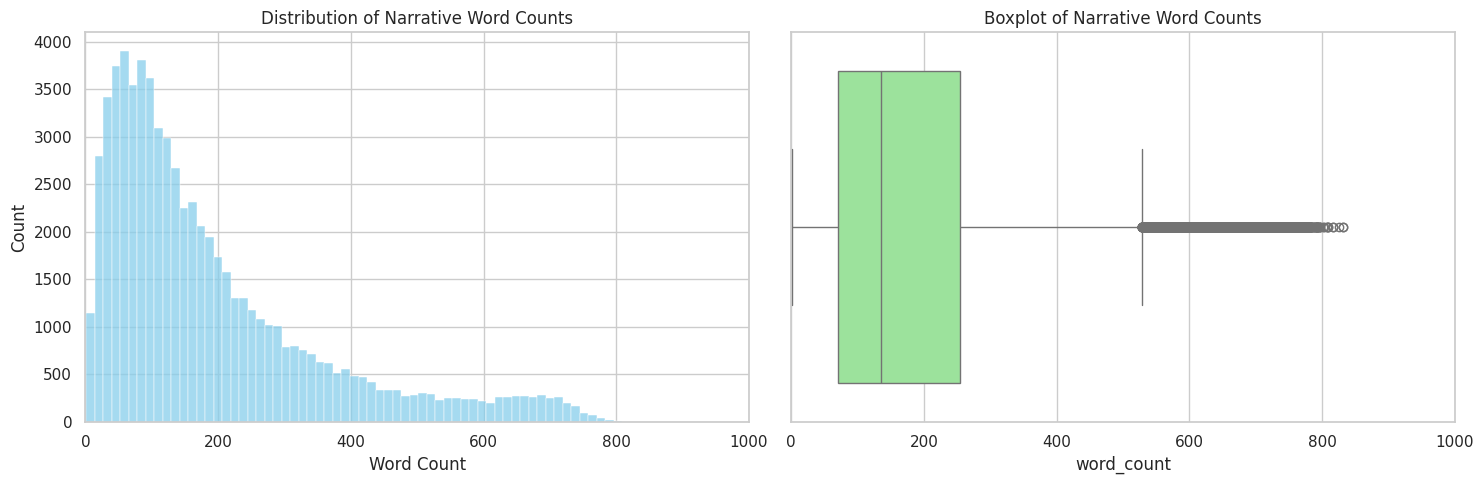


📊 Narrative Statistics:
count    66806.000000
mean       190.644014
std        166.830597
min          1.000000
25%         71.000000
50%        136.000000
75%        254.000000
max       1284.000000
Name: word_count, dtype: float64
⚠️ Detected 4,374 outliers (length > 528 words).


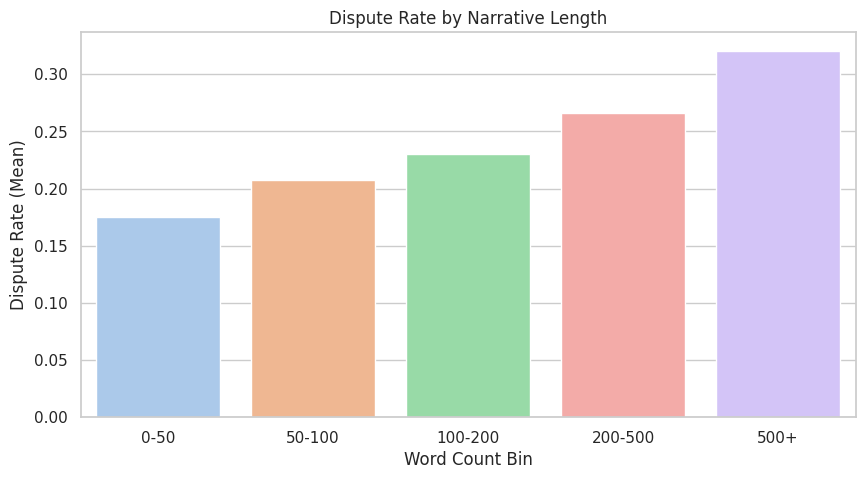

📊 Analysis: Does complaint length influence dispute likelihood?

Generating Word Cloud (sampling 10,000 narratives)...


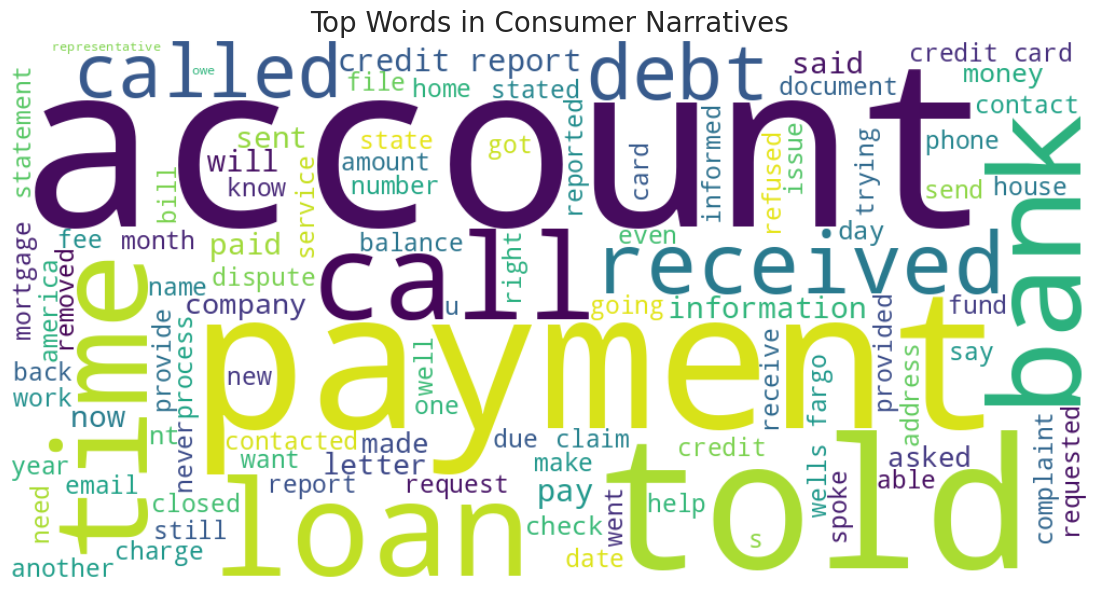


DATA LEAKAGE CHECK
Duplicate narratives found: 1,160 (1.74%)
⚠️ Recommendation: Remove exact duplicates before training to prevent leakage.


In [ ]:
# CELL 3.2: NARRATIVE & TEXT ANALYSIS (CORRECTED)

import subprocess
import sys

# Install missing libraries
def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

install_if_missing("wordcloud")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Check for narrative column
narrative_col = 'consumer_complaint_narrative'
if narrative_col not in df.columns:
    raise ValueError(f"Column {narrative_col} not found.")

# Filter out null narratives for text analysis
df_text = df.dropna(subset=[narrative_col]).copy()
print(f"Analyzing {len(df_text):,} non-null narratives...")

# 1. Narrative Length Analysis
# ----------------------------
df_text['word_count'] = df_text[narrative_col].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.histplot(df_text['word_count'], bins=100, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Narrative Word Counts')
axes[0].set_xlabel('Word Count')
axes[0].set_xlim(0, 1000) # Limit x-axis for visibility

# Boxplot
sns.boxplot(x=df_text['word_count'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Narrative Word Counts')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

print(f"\n📊 Narrative Statistics:")
print(df_text['word_count'].describe())

# 2. Outlier Detection (Length)
# -----------------------------
q1 = df_text['word_count'].quantile(0.25)
q3 = df_text['word_count'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outliers = df_text[df_text['word_count'] > upper_bound]
print(f"⚠️ Detected {len(outliers):,} outliers (length > {upper_bound:.0f} words).")

# 3. Correlation: Length vs Dispute
# ---------------------------------
if 'consumer_disputed?' in df.columns:
    # Map only if values exist
    if df_text['consumer_disputed?'].isin(['Yes', 'No']).any():
        df_text['disputed_flag'] = df_text['consumer_disputed?'].map({'Yes': 1, 'No': 0})

        # Group by length bins
        df_text['length_bin'] = pd.cut(df_text['word_count'], bins=[0, 50, 100, 200, 500, 10000], labels=['0-50', '50-100', '100-200', '200-500', '500+'])

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=df_text, x='length_bin', y='disputed_flag', ax=ax, hue='length_bin', palette='pastel', legend=False, errorbar=None)
        ax.set_title('Dispute Rate by Narrative Length')
        ax.set_ylabel('Dispute Rate (Mean)')
        ax.set_xlabel('Word Count Bin')
        plt.show()
        print("📊 Analysis: Does complaint length influence dispute likelihood?")

# 4. Word Frequency & WordCloud
# -----------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'xxxx|xx/xx/xxxx', '', text) # Remove redaction tokens
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

print("\nGenerating Word Cloud (sampling 10,000 narratives)...")
sample_text = ' '.join(df_text[narrative_col].sample(min(10000, len(df_text)), random_state=42).apply(clean_text))

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=100).generate(sample_text)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Words in Consumer Narratives', fontsize=20)
plt.show()

# 5. Data Leakage Check
# ---------------------
print("\n" + "="*50)
print("DATA LEAKAGE CHECK")
print("="*50)
duplicate_count = df_text[narrative_col].duplicated().sum()
print(f"Duplicate narratives found: {duplicate_count:,} ({(duplicate_count/len(df_text))*100:.2f}%)")
if duplicate_count > 0:
    print("⚠️ Recommendation: Remove exact duplicates before training to prevent leakage.")

Calculating TF-IDF (sampling 10,000 documents)...


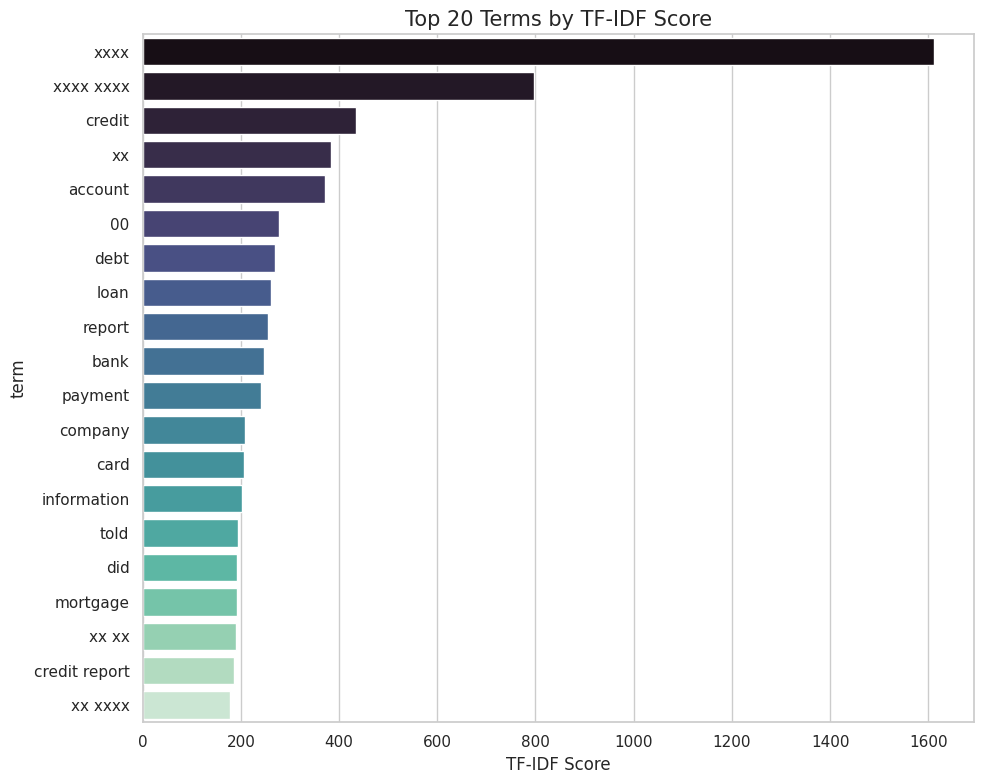


Running BERTopic (sampling 5,000 documents for performance)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Visualizing Top 10 Topics...



Correlation Analysis between Categorical Features...


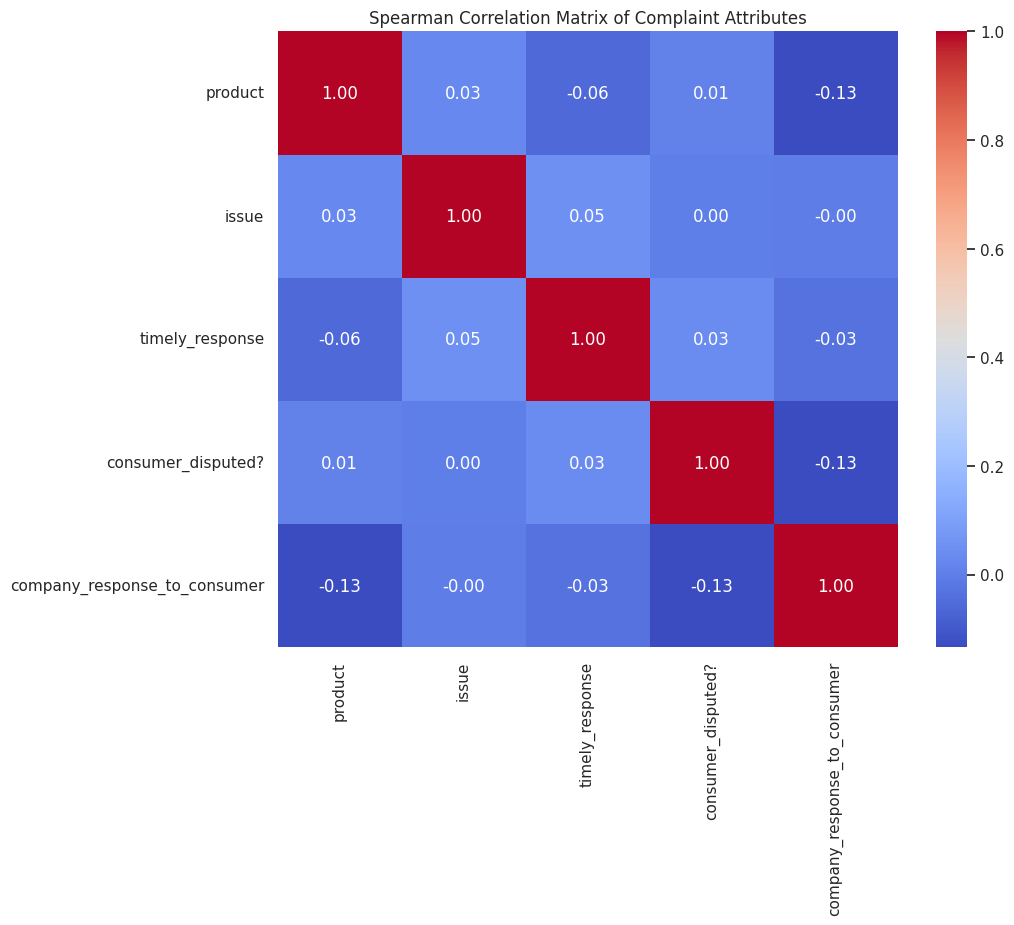


✅ PHASE 3 (EDA) COMPLETED.
Key Insights Generated: Product distribution, Issue frequency, Narrative length stats, Topic clusters, Correlations.


In [ ]:
# CELL 3.3: ADVANCED TEXT ANALYSIS & TOPIC MODELING

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Check for narrative column
narrative_col = 'consumer_complaint_narrative'
df_text = df.dropna(subset=[narrative_col]).copy()

# 1. TF-IDF Visualization
# -----------------------
print("Calculating TF-IDF (sampling 10,000 documents)...")
# Use a sample for performance
sample_docs = df_text[narrative_col].sample(min(10000, len(df_text)), random_state=42).astype(str).tolist()

# Initialize TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf_vec.fit_transform(sample_docs)

# Sum TF-IDF scores for each term
sums = tfidf_matrix.sum(axis=0)
terms = tfidf_vec.get_feature_names_out()
tfidf_scores = np.array(sums).flatten()

# Create DataFrame of top terms
tfidf_df = pd.DataFrame({'term': terms, 'score': tfidf_scores})
tfidf_df = tfidf_df.sort_values(by='score', ascending=False).head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=tfidf_df, y='term', x='score', palette='mako', hue='term', legend=False)
ax.set_title('Top 20 Terms by TF-IDF Score', fontsize=15)
ax.set_xlabel('TF-IDF Score')
plt.tight_layout()
plt.show()

# 2. Topic Modeling with BERTopic
# -------------------------------
print("\nRunning BERTopic (sampling 5,000 documents for performance)...")
# Use a smaller sample for BERTopic to fit in memory/time constraints in EDA
topic_docs = df_text[narrative_col].sample(min(5000, len(df_text)), random_state=42).astype(str).tolist()

# Use a lightweight sentence transformer model for speed
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Initialize BERTopic
# We reduce outliers to get cleaner topics
topic_model = BERTopic(embedding_model=embedding_model, language="english", calculate_probabilities=False, verbose=False)
topics, probs = topic_model.fit_transform(topic_docs)

# Visualize Top Topics
print("Visualizing Top 10 Topics...")
fig = topic_model.visualize_barchart(top_n_topics=10, n_words=5, width=300, height=400)
fig.show()

# 3. Correlation Analysis
# -----------------------
print("\nCorrelation Analysis between Categorical Features...")
# Select categorical columns for correlation
cat_cols = ['product', 'issue', 'timely_response', 'consumer_disputed?', 'company_response_to_consumer']

# Encode columns
df_encoded = df_text[cat_cols].copy()
df_encoded = df_encoded.dropna()

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Calculate correlation matrix
corr_matrix = df_encoded.corr(method='spearman')

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
ax.set_title('Spearman Correlation Matrix of Complaint Attributes')
plt.show()

print("\n✅ PHASE 3 (EDA) COMPLETED.")
print("Key Insights Generated: Product distribution, Issue frequency, Narrative length stats, Topic clusters, Correlations.")

In [ ]:
# CELL 4: DATA PREPROCESSING

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle
import os

print("Starting Data Preprocessing...")

# 1. Filter Null Narratives
# -------------------------
# We only need rows with narratives for Case-Based RAG
df_processed = df.dropna(subset=['consumer_complaint_narrative']).copy()
print(f"✅ Rows after filtering null narratives: {len(df_processed):,}")

# 2. Text Cleaning Pipeline
# -------------------------
def clean_complaint_text(text):
    """
    Cleans individual complaint narrative.
    - Lowers case
    - Removes PII redaction tokens (XXXX, XX/XX/XXXX)
    - Removes special characters/punctuation
    - Removes extra whitespace
    """
    text = str(text).lower()

    # Remove specific redaction patterns common in this dataset
    text = re.sub(r'xx/xx/xxxx', '', text)
    text = re.sub(r'xxxx', '', text)
    text = re.sub(r'xx', '', text)

    # Remove non-alphanumeric characters (keep spaces)
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("Cleaning text narratives...")
df_processed['cleaned_narrative'] = df_processed['consumer_complaint_narrative'].apply(clean_complaint_text)

# 3. Remove Duplicates & Short Texts
# ----------------------------------
# Remove duplicates based on cleaned text
initial_count = len(df_processed)
df_processed = df_processed.drop_duplicates(subset=['cleaned_narrative'])
print(f"✅ Removed {initial_count - len(df_processed):,} duplicate narratives.")

# Remove very short narratives (less than 10 words) as they carry little semantic meaning
df_processed = df_processed[df_processed['cleaned_narrative'].str.split().str.len() > 10]
print(f"✅ Remaining rows after removing short texts: {len(df_processed):,}")

# 4. Label Encoding
# -----------------
# We need to encode labels for Agent 1 (Classification tasks)
label_cols = ['product', 'issue', 'consumer_disputed?', 'company_response_to_consumer']
encoders = {}

print("\nEncoding labels...")
for col in label_cols:
    if col in df_processed.columns:
        le = LabelEncoder()
        # Handle potential NaN values in non-target columns just in case
        df_processed[col] = df_processed[col].fillna('Unknown')
        df_processed[f'{col}_enc'] = le.fit_transform(df_processed[col].astype(str))
        encoders[col] = le
        print(f"  - Encoded '{col}': {len(le.classes_)} classes")
    else:
        print(f"  - Skipping '{col}': Not found in dataframe")

# 5. Train/Validation/Test Split
# ------------------------------
# We stratify by 'product' to maintain distribution
X = df_processed['cleaned_narrative']
y = df_processed['product_enc'] # Stratify target

# Split into Train (80%) and Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split Temp into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"\n📊 Dataset Splits:")
print(f"  Training Set:   {len(X_train):,} samples")
print(f"  Validation Set: {len(X_val):,} samples")
print(f"  Test Set:       {len(X_test):,} samples")

# Reconstruct DataFrames for Agents
# We need the full metadata for the RAG knowledge base, not just X/y
# We use the indices from the split to reconstruct full DFs
train_df = df_processed.loc[X_train.index].reset_index(drop=True)
val_df = df_processed.loc[X_val.index].reset_index(drop=True)
test_df = df_processed.loc[X_test.index].reset_index(drop=True)

# 6. Save Processed Data
# ----------------------
# Save to disk for persistence
processed_dir = "processed_data"
os.makedirs(processed_dir, exist_ok=True)

train_df.to_pickle(f"{processed_dir}/train_df.pkl")
val_df.to_pickle(f"{processed_dir}/val_df.pkl")
test_df.to_pickle(f"{processed_dir}/test_df.pkl")

# Save encoders
with open(f"{processed_dir}/label_encoders.pkl", 'wb') as f:
    pickle.dump(encoders, f)

print(f"\n✅ Processed data saved to '{processed_dir}/'")
print("✅ PHASE 4 (PREPROCESSING) COMPLETED.")

Starting Data Preprocessing...
✅ Rows after filtering null narratives: 66,806
Cleaning text narratives...
✅ Removed 1,334 duplicate narratives.
✅ Remaining rows after removing short texts: 64,751

Encoding labels...
  - Encoded 'product': 11 classes
  - Encoded 'issue': 90 classes
  - Encoded 'consumer_disputed?': 2 classes
  - Encoded 'company_response_to_consumer': 5 classes

📊 Dataset Splits:
  Training Set:   51,800 samples
  Validation Set: 6,475 samples
  Test Set:       6,476 samples

✅ Processed data saved to 'processed_data/'
✅ PHASE 4 (PREPROCESSING) COMPLETED.


Loading processed data...
Target: Product Classification (11 classes)
Model: distilbert-base-uncased
Initializing tokenizer...
Initializing model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting Training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.445960,0.419554,0.869035,0.727095,0.867526,0.718327,0.740742
2,0.314700,0.380466,0.882471,0.748137,0.881037,0.748768,0.749034


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Evaluating on Validation Set...


{'eval_loss': 0.380466490983963, 'eval_accuracy': 0.8824710424710425, 'eval_macro_f1': 0.7481373873729446, 'eval_weighted_f1': 0.8810370966179086, 'eval_macro_precision': 0.7487676988263797, 'eval_macro_recall': 0.7490337941601877, 'eval_runtime': 6.0428, 'eval_samples_per_second': 1071.522, 'eval_steps_per_second': 33.594, 'epoch': 2.0}

Classification Report:
                         precision    recall  f1-score   support

Bank account or service       0.86      0.77      0.81       565
          Consumer Loan       0.78      0.73      0.75       364
            Credit card       0.84      0.88      0.86       784
       Credit reporting       0.91      0.90      0.91      1143
        Debt collection       0.88      0.89      0.88      1688
        Money transfers       0.76      0.73      0.74        66
               Mortgage       0.95      0.97      0.96      1485
Other financial service       0.00      0.00      0.00        11
            Payday loan       0.59      0.57      

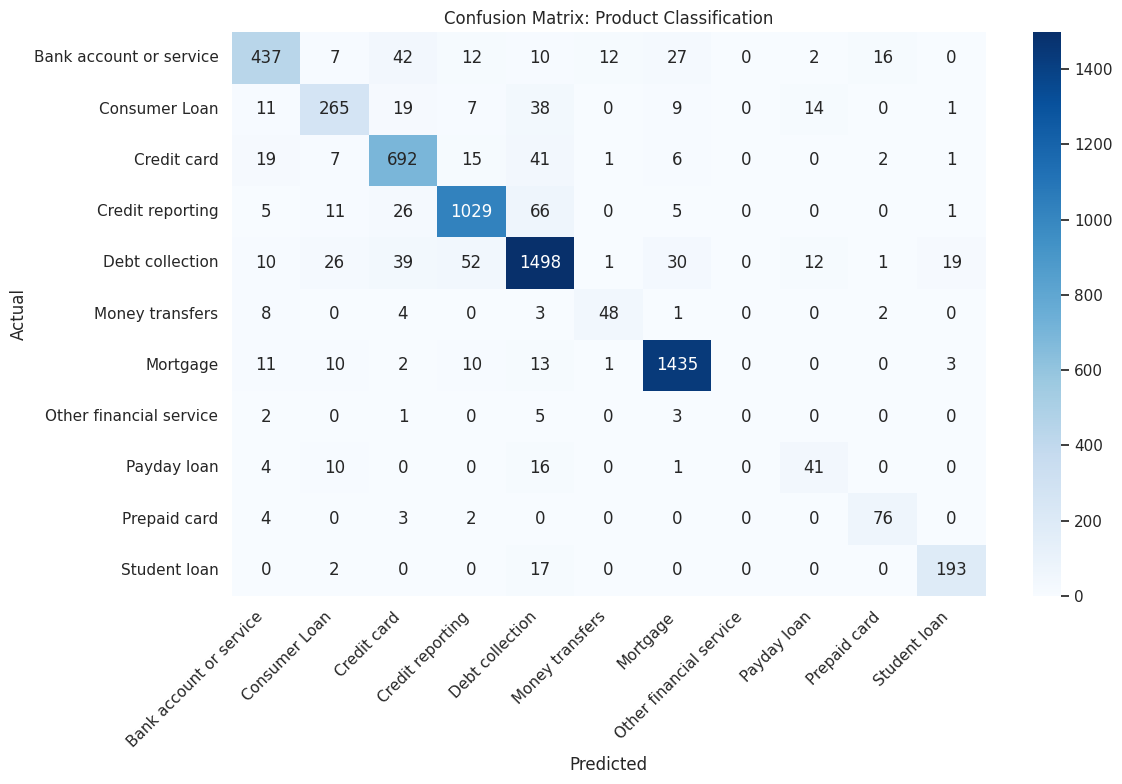

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Agent 1 Model saved to ./agent1_product_classifier
PHASE 5 (AGENT 1 TRAINING) COMPLETED.


In [ ]:
# CELL 5: AGENT 1 TRAINING (CORRECTED API & METRICS)

import torch
import pandas as pd
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from torch.utils.data import Dataset
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os
import warnings

# Suppress warnings about weight initialization
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Configuration & Setup
# ------------------------
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256
BATCH_SIZE = 32
EPOCHS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading processed data...")
train_df = pd.read_pickle("processed_data/train_df.pkl")
val_df = pd.read_pickle("processed_data/val_df.pkl")

with open("processed_data/label_encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

num_labels = len(encoders['product'].classes_)
print(f"Target: Product Classification ({num_labels} classes)")
print(f"Model: {MODEL_NAME}")

# 2. Prepare Dataset Class
# ------------------------
class ComplaintDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Initialize Tokenizer
print("Initializing tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Create Datasets
train_dataset = ComplaintDataset(
    texts=train_df['cleaned_narrative'].values,
    labels=train_df['product_enc'].values,
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

val_dataset = ComplaintDataset(
    texts=val_df['cleaned_narrative'].values,
    labels=val_df['product_enc'].values,
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

# 3. Metrics Function
# -------------------
def compute_metrics(p):
    pred, labels = p
    pred = np.argmax(pred, axis=1)

    acc = accuracy_score(labels, pred)
    f1_macro = f1_score(labels, pred, average='macro')
    f1_weighted = f1_score(labels, pred, average='weighted')
    precision_macro = precision_score(labels, pred, average='macro', zero_division=0)
    recall_macro = recall_score(labels, pred, average='macro', zero_division=0)

    return {
        'accuracy': acc,
        'macro_f1': f1_macro,
        'weighted_f1': f1_weighted,
        'macro_precision': precision_macro,
        'macro_recall': recall_macro
    }

# 4. Initialize Model
# -------------------
print("Initializing model...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
).to(device)

# 5. Training Arguments
# ---------------------
training_args = TrainingArguments(
    output_dir='./agent1_results',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./agent1_logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    report_to="none",
    fp16=True if device.type == 'cuda' else False
)

# 6. Train
# --------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Starting Training...")
trainer.train()

# 7. Evaluation
# -------------
print("\nEvaluating on Validation Set...")
metrics = trainer.evaluate()
print(metrics)

# Detailed Classification Report
raw_pred, _, _ = trainer.predict(val_dataset)
y_pred = np.argmax(raw_pred, axis=1)
y_true = val_df['product_enc'].values

target_names = encoders['product'].classes_

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Product Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 8. Save Model
# -------------
model_path = "./agent1_product_classifier"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f"Agent 1 Model saved to {model_path}")

print("PHASE 5 (AGENT 1 TRAINING) COMPLETED.")

In [ ]:
# [CELL 6: CASE-BASED RAG IMPLEMENTATION (FAISS)]

import time
import numpy as np
import pandas as pd
import faiss
import torch
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# 0. Safety Check for Notebook State
# ------------------------------
if 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[WARNING] 'DEVICE' was not found in memory. Re-initialized as: {DEVICE}")

# 1. Load Data
# ------------------------------
print("[INFO] Loading data...")
try:
    train_df = pd.read_pickle("processed_data/train_df.pkl")
    test_df = pd.read_pickle("processed_data/test_df.pkl")
except FileNotFoundError:
    print("[WARNING] Pickles not found. Assuming data exists in memory.")
    pass

# 2. Initialize Embedding Model
# ------------------------------
print("[INFO] Loading Embedding Model...")
embedding_model_name = 'all-MiniLM-L6-v2'
embedder = SentenceTransformer(embedding_model_name, device=DEVICE)

# 3. Create Embeddings & FAISS Index
# ----------------------
print(f"[INFO] Encoding {len(train_df)} historical narratives...")
train_embeddings = embedder.encode(
    train_df['cleaned_narrative'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True,
    device=DEVICE
)

# Build FAISS Index (Inner Product for Cosine Similarity)
embedding_dim = train_embeddings.shape[1]
index = faiss.IndexFlatIP(embedding_dim)

# Safely check for faiss-gpu capabilities
if torch.cuda.is_available() and hasattr(faiss, 'StandardGpuResources'):
    print("[INFO] faiss-gpu detected. Moving index to GPU...")
    res = faiss.StandardGpuResources()
    index = faiss.index_cpu_to_gpu(res, 0, index)
else:
    if torch.cuda.is_available():
        print("[WARNING] PyTorch GPU detected, but faiss-gpu is missing. Running FAISS index on CPU.")
    else:
        print("[INFO] Running FAISS index on CPU.")

index.add(train_embeddings)
print(f"✅ FAISS Index populated with {index.ntotal} vectors.")

# 4. Retrieval Pipeline
# ---------------------
def retrieve_similar_cases_faiss(query_text: str, k: int = 5):
    """
    Retrieves top-k similar historical complaints using FAISS.
    """
    query_vector = embedder.encode([query_text], normalize_embeddings=True, device=DEVICE)
    distances, indices = index.search(query_vector, k)

    retrieved_cases = []
    for i, idx in enumerate(indices[0]):
        if idx == -1: continue

        row = train_df.iloc[idx]
        case = {
            'id': row.name,
            'document': row['cleaned_narrative'],
            'metadata': {
                'product': row['product'],
                'issue': row['issue'],
                'company_response': row['company_response_to_consumer'],
                'timely': row['timely_response'],
                'disputed': row['consumer_disputed?']
            },
            'similarity_score': distances[0][i]
        }
        retrieved_cases.append(case)

    return retrieved_cases

# 5. Evaluate Retrieval System
# ---------------------------------
print("\n📊 Evaluating Retrieval Quality (Heuristic: Product Match)...")

eval_samples = test_df.sample(n=min(100, len(test_df)), random_state=42)
k_val = 5

precisions = []
recalls = []
reciprocal_ranks = []

for _, row in tqdm(eval_samples.iterrows(), total=len(eval_samples), desc="Evaluating RAG"):
    query_text = row['cleaned_narrative']
    true_product = row['product']

    retrieved = retrieve_similar_cases_faiss(query_text, k=k_val)

    relevant_count = 0
    query_rr = 0.0

    for rank, case in enumerate(retrieved):
        if case['metadata']['product'] == true_product:
            relevant_count += 1
            if query_rr == 0.0:
                query_rr = 1.0 / (rank + 1)

    precision_at_k = relevant_count / k_val
    recall_at_k = 1.0 if relevant_count > 0 else 0.0

    precisions.append(precision_at_k)
    recalls.append(recall_at_k)
    reciprocal_ranks.append(query_rr)

print("\n--- FAISS Retrieval Metrics ---")
print(f"Precision@{k_val}: {np.mean(precisions):.4f}")
print(f"Recall@{k_val}:    {np.mean(recalls):.4f} (Queries with at least 1 relevant case)")
print(f"MRR:             {np.mean(reciprocal_ranks):.4f}")
print("-------------------------------")
print("\n✅ PHASE 6 (RAG IMPLEMENTATION) COMPLETED.")

[INFO] Loading data...
[INFO] Loading Embedding Model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[INFO] Encoding 51800 historical narratives...


Batches:   0%|          | 0/405 [00:00<?, ?it/s]

[WARNING] PyTorch GPU detected, but faiss-gpu is missing. Running FAISS index on CPU.
✅ FAISS Index populated with 51800 vectors.

📊 Evaluating Retrieval Quality (Heuristic: Product Match)...


Evaluating RAG: 100%|██████████| 100/100 [00:01<00:00, 89.14it/s]


--- FAISS Retrieval Metrics ---
Precision@5: 0.7360
Recall@5:    0.9400 (Queries with at least 1 relevant case)
MRR:             0.8600
-------------------------------

✅ PHASE 6 (RAG IMPLEMENTATION) COMPLETED.


In [ ]:
# [REPLACEMENT CELL 7: UPGRADED AGENT 3 - MISTRAL/ZEPHYR 7B]

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings
import random
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Ensure NLTK tokenizer resources are downloaded
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# 0. Install Quantization & Metric Dependencies
# -------------------------------------------
import subprocess
import sys
try:
    import bitsandbytes
    import accelerate
    import rouge_score
    import bert_score
except ImportError:
    print("[INFO] Installing bitsandbytes, accelerate, and metrics...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "bitsandbytes", "accelerate", "rouge_score", "bert_score", "nltk", "-q"])
    import rouge_score
    import bert_score

from rouge_score import rouge_scorer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

if 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Configuration & 4-bit Quantized Model Loading
# ------------------------------------------------
print("[INFO] Loading Generator Model (Zephyr-7B-beta) in 4-bit Quantization...")
gen_model_name = "HuggingFaceH4/zephyr-7b-beta" # Un-gated Mistral-7B fine-tune

# Configure 4-bit quantization to save VRAM
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer_gen = AutoTokenizer.from_pretrained(gen_model_name)
# Causal LMs don't have pad tokens by default; set it to eos_token to avoid warnings
tokenizer_gen.pad_token = tokenizer_gen.eos_token

model_gen = AutoModelForCausalLM.from_pretrained(
    gen_model_name,
    quantization_config=bnb_config,
    device_map="auto" # Let accelerate handle GPU placement
)

# 2. Prompt Engineering (Chat Template)
# -------------------------------------
def create_report_prompt(new_complaint: str, retrieved_cases: list) -> str:
    """
    Constructs a prompt using the specific <|system|>, <|user|>, <|assistant|> template.
    """
    context_str = ""
    for i, case in enumerate(retrieved_cases):
        context_str += f"Historical Case {i+1}:\n"
        context_str += f"- Product: {case['metadata']['product']}\n"
        context_str += f"- Issue: {case['metadata']['issue']}\n"
        context_str += f"- Resolution: {case['metadata']['company_response']}\n"
        context_str += f"- Disputed: {case['metadata']['disputed']}\n"
        context_str += f"- Narrative Excerpt: {case['document'][:200]}...\n\n"

    # Zephyr/Mistral Chat Template formatting
    messages = [
        {
            "role": "system",
            "content": "You are a Senior Financial Compliance Officer. Your task is to write a brief, strictly formatted report based on a new complaint and similar historical cases."
        },
        {
            "role": "user",
            "content": f"New Complaint:\n{new_complaint}\n\nSimilar Historical Cases:\n{context_str}\n\nBased strictly on the historical cases above, write a report for the new complaint with exactly these four sections:\n1. Executive Summary:\n2. Precedent Analysis:\n3. Predicted Resolution:\n4. Recommended Action:"
        }
    ]

    # Apply the tokenizer's built-in chat template to format the prompt perfectly
    prompt = tokenizer_gen.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt

# 3. Generation Function
# ----------------------
def generate_structured_report(new_complaint: str, retrieved_cases: list) -> str:
    prompt = create_report_prompt(new_complaint, retrieved_cases)

    inputs = tokenizer_gen(prompt, return_tensors="pt", max_length=2048, truncation=True).to(model_gen.device)

    with torch.no_grad():
        outputs = model_gen.generate(
            **inputs,
            max_new_tokens=256, # Use max_new_tokens for CausalLMs
            do_sample=False,    # Deterministic inference
            pad_token_id=tokenizer_gen.eos_token_id
        )

    # Slicing the output to remove the prompt from the generated text
    input_length = inputs.input_ids.shape[1]
    generated_tokens = outputs[0][input_length:]
    report = tokenizer_gen.decode(generated_tokens, skip_special_tokens=True)

    return report.strip()

# 4. Fallback for Retrieval
# -------------------------
if 'retrieve_similar_cases_faiss' not in globals():
    print("[WARNING] Retrieval function missing. Creating fallback.")
    def retrieve_similar_cases_faiss(query_text, k=3): return []

# 5. Batch Evaluation (Groundedness, ROUGE, BLEU)
# -----------------------------------------------
print("\n📊 Evaluating Generation Groundedness (Running mini-batch of 5 samples)...")

eval_samples = test_df.sample(n=min(5, len(test_df)), random_state=42)

rouge_scorer_inst = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
smooth_func = SmoothingFunction().method1

bert_f1_scores = []
rouge1_scores = []
rougel_scores = []
bleu_scores = []

sample_display_report = ""

for idx, row in tqdm(eval_samples.iterrows(), total=len(eval_samples), desc="Generating Reports"):
    complaint = row['cleaned_narrative']
    retrieved = retrieve_similar_cases_faiss(complaint, k=3)

    report = generate_structured_report(complaint, retrieved)
    sample_display_report = report

    context_text = " ".join([c['document'] for c in retrieved])

    if context_text.strip():
        P, R, F1 = bert_score.score([report], [context_text], lang="en", verbose=False, device=DEVICE)
        bert_f1_scores.append(F1.item())

        r_scores = rouge_scorer_inst.score(context_text, report)
        rouge1_scores.append(r_scores['rouge1'].fmeasure)
        rougel_scores.append(r_scores['rougeL'].fmeasure)

        ref_tokens = [nltk.word_tokenize(context_text)]
        cand_tokens = nltk.word_tokenize(report)
        b_score = sentence_bleu(ref_tokens, cand_tokens, smoothing_function=smooth_func)
        bleu_scores.append(b_score)

print("\n--- Upgraded Generation Metrics (Average over batch) ---")
print(f"Groundedness (BERTScore F1): {np.mean(bert_f1_scores):.4f}")
print(f"Context Overlap (ROUGE-1):   {np.mean(rouge1_scores):.4f}")
print(f"Context Overlap (ROUGE-L):   {np.mean(rougel_scores):.4f}")
print(f"Context Exact Phrase (BLEU): {np.mean(bleu_scores):.4f}")
print("--------------------------------------------------------")

print("\n📜 UPGRADED SAMPLE GENERATED STRUCTURED REPORT:")
print("="*50)
print(sample_display_report)
print("="*50)

print("\n✅ REPLACEMENT PHASE 7 (UPGRADED REPORT GENERATOR) COMPLETED.")

[INFO] Installing bitsandbytes, accelerate, and metrics...
[INFO] Loading Generator Model (Zephyr-7B-beta) in 4-bit Quantization...


config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Generating Reports:  80%|████████  | 4/5 [00:59<00:14, 14.96s/it]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Generating Reports: 100%|██████████| 5/5 [01:14<00:00, 14.87s/it]


--- Upgraded Generation Metrics (Average over batch) ---
Groundedness (BERTScore F1): 0.8152
Context Overlap (ROUGE-1):   0.2447
Context Overlap (ROUGE-L):   0.1339
Context Exact Phrase (BLEU): 0.0127
--------------------------------------------------------

📜 UPGRADED SAMPLE GENERATED STRUCTURED REPORT:
Executive Summary:

The new complaint involves a judgment obtained against the complainant for a credit card debt without proper notification. The complainant has discovered this judgment through a court system website and has found evidence of unsuccessful attempts to serve the paperwork. The complainant believes that the judgment should be overturned based on the affidavit of service indicating that the complainant received the subpoena before moving to their current address. This report will analyze similar historical cases to provide guidance on the complainant's next steps.

Precedent Analysis:

Historical Case 1 involves a debt collection issue where the complainant disputed the

In [ ]:
# [ULTIMATE CELL 7: AGENT 3 - QWEN2.5-7B-INSTRUCT - VERIFIABLE VERSION]

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings
import random
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Ensure NLTK tokenizer resources are downloaded
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from rouge_score import rouge_scorer
import bert_score

if 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Configuration & 4-bit Quantized Model Loading
# ------------------------------------------------
print("[INFO] Loading Generator Model (Qwen2.5-7B-Instruct) in 4-bit Quantization...")
gen_model_name = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer_gen = AutoTokenizer.from_pretrained(gen_model_name)
model_gen = AutoModelForCausalLM.from_pretrained(
    gen_model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

# 2. Hardened Verifiable Prompt Engineering
# ------------------------------
def create_report_prompt(new_complaint: str, retrieved_cases: list) -> str:
    """
    Constructs a prompt with numbered sources to force in-text citations.
    """
    context_str = ""
    for i, case in enumerate(retrieved_cases):
        # We assign a [CASE_X] tag to each retrieval for anchoring
        context_str += f"[CASE {i+1}]:\n"
        context_str += f"- Product: {case['metadata']['product']}\n"
        context_str += f"- Resolution: {case['metadata']['company_response']}\n"
        context_str += f"- Context: {case['document'][:350]}...\n\n"

    messages = [
        {
            "role": "system",
            "content": (
                "You are a Senior Financial Compliance Auditor. You write strictly factual reports. "
                "For every claim made in your analysis, you MUST cite the case used by adding [CASE X] at the end of the sentence. "
                "If information is not in the cases, do not invent it. Use deterministic, greedy language."
            )
        },
        {
            "role": "user",
            "content": f"HISTORICAL PRECEDENTS:\n{context_str}\n\nNEW COMPLAINT:\n{new_complaint}\n\n"
                       f"Write a report with these headers:\n1. Executive Summary\n2. Precedent-Based Analysis (with citations)\n3. Predicted Resolution\n4. Recommended Action"
        }
    ]

    prompt = tokenizer_gen.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt

# 3. Deterministic Generation Function
# ----------------------
def generate_structured_report(new_complaint: str, retrieved_cases: list) -> str:
    prompt = create_report_prompt(new_complaint, retrieved_cases)

    inputs = tokenizer_gen(prompt, return_tensors="pt", max_length=2048, truncation=True).to(model_gen.device)

    with torch.no_grad():
        outputs = model_gen.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False, # GREEDY DECODING: Best for preventing hallucinations
            pad_token_id=tokenizer_gen.eos_token_id
        )

    input_length = inputs.input_ids.shape[1]
    generated_tokens = outputs[0][input_length:]
    report = tokenizer_gen.decode(generated_tokens, skip_special_tokens=True)

    return report.strip()

# 4. Fallback for Retrieval
# -------------------------
if 'retrieve_similar_cases_faiss' not in globals():
    print("[WARNING] Retrieval function missing. Creating fallback.")
    def retrieve_similar_cases_faiss(query_text, k=3): return []

# 5. Batch Evaluation (Groundedness & Citation Consistency)
# -----------------------------------------------
print("\n📊 Evaluating Low-Hallucination Pipeline (Running mini-batch of 5 samples)...")

eval_samples = test_df.sample(n=min(5, len(test_df)), random_state=42)

rouge_scorer_inst = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
smooth_func = SmoothingFunction().method1

bert_f1_scores = []
rougeL_scores = []
bleu_scores = []

sample_display_report = ""

for idx, row in tqdm(eval_samples.iterrows(), total=len(eval_samples), desc="Generating Reports"):
    complaint = row['cleaned_narrative']
    retrieved = retrieve_similar_cases_faiss(complaint, k=3)

    report = generate_structured_report(complaint, retrieved)
    sample_display_report = report

    context_text = " ".join([c['document'] for c in retrieved])

    if context_text.strip():
        P, R, F1 = bert_score.score([report], [context_text], lang="en", verbose=False, device=DEVICE)
        bert_f1_scores.append(F1.item())

        r_scores = rouge_scorer_inst.score(context_text, report)
        rougeL_scores.append(r_scores['rougeL'].fmeasure)

        ref_tokens = [nltk.word_tokenize(context_text)]
        cand_tokens = nltk.word_tokenize(report)
        b_score = sentence_bleu(ref_tokens, cand_tokens, smoothing_function=smooth_func)
        bleu_scores.append(b_score)

print("\n--- Verifiable Generation Metrics (Average over batch) ---")
print(f"Groundedness (BERTScore F1): {np.mean(bert_f1_scores):.4f}")
print(f"Faithfulness (ROUGE-L):     {np.mean(rougeL_scores):.4f}")
print(f"Phrase Precision (BLEU):    {np.mean(bleu_scores):.4f}")
print("--------------------------------------------------------")

print("\n📜 SAMPLE GENERATED REPORT (Check for [CASE X] tags):")
print("="*50)
print(sample_display_report)
print("="*50)

print("\n✅ ULTIMATE PHASE 7 (VERIFIABLE QWEN GENERATOR) COMPLETED.")

[INFO] Loading Generator Model (Qwen2.5-7B-Instruct) in 4-bit Quantization...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


📊 Evaluating Low-Hallucination Pipeline (Running mini-batch of 5 samples)...


Generating Reports:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Generating Reports:  80%|████████  | 4/5 [01:38<00:24, 24.73s/it]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Generating Reports: 100%|██████████| 5/5 [02:03<00:00, 24.72s/it]


--- Verifiable Generation Metrics (Average over batch) ---
Groundedness (BERTScore F1): 0.8038
Faithfulness (ROUGE-L):     0.1553
Phrase Precision (BLEU):    0.0206
--------------------------------------------------------

📜 SAMPLE GENERATED REPORT (Check for [CASE X] tags):
### Executive Summary
The complainant has discovered a judgment against them for $400,000 related to a credit card debt, which they claim was obtained without proper notification or service of process. The complainant argues that the judgment should be overturned due to the improper service of the paperwork and the expiration of the statute of limitations. This report analyzes the situation using historical precedents and provides recommendations for action.

### Precedent-Based Analysis (with Citations)

1. **Service of Process**:
   - In [CASE 1], the complainant was unaware of a lawsuit against them because the debt collectors did not properly serve the necessary documents. The court found that the complainant 

In [ ]:
# [CELL 9.1: CORRECTED HALLUCINATION AUDIT]

import pandas as pd
from rouge_score import rouge_scorer

def run_deep_hallucination_audit(report: str, retrieved_cases: list) -> dict:
    """
    Analyzes the report for factual consistency against retrieved precedents.
    """
    if not retrieved_cases:
        return {"error": "No context provided for audit"}

    # 1. Prepare context for lexical comparison
    context_text = " ".join([c['document'] for c in retrieved_cases])

    # 2. Calculate Faithfulness (ROUGE-L overlap with Context)
    # This measures how much the report "sticks" to the source text
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    faithfulness_score = scorer.score(context_text, report)['rougeL'].fmeasure

    # 3. Metadata Compliance (Hard Check)
    # We verify that the 'Product' labels from retrieval appear in the generated report
    context_products = set(c['metadata']['product'].lower() for c in retrieved_cases)
    report_lower = report.lower()

    # Check if the model invented a product not in the source cases
    product_match = any(p in report_lower for p in context_products) if context_products else False

    # 4. Decision Logic
    risk_level = "LOW"
    if faithfulness_score < 0.1 or not product_match:
        risk_level = "HIGH"
    elif faithfulness_score < 0.2:
        risk_level = "MEDIUM"

    return {
        "faithfulness_score": round(faithfulness_score, 4),
        "metadata_consistent": product_match,
        "overall_hallucination_risk": risk_level,
        "recommendation": "PROCEED" if risk_level == "LOW" else "HUMAN_AUDIT_REQUIRED"
    }

# ------------------------------------------------------------
# EXECUTE AUDIT ON THE LATEST GENERATED SAMPLE
# ------------------------------------------------------------
print("🛡️ Auditing Pipeline for Hallucinations...")

# Using variables 'sample_display_report' and 'retrieved' from the successful Phase 7/8 runs
try:
    audit_results = run_deep_hallucination_audit(sample_display_report, retrieved)

    # Display Audit Table
    audit_df = pd.DataFrame([audit_results])
    print("\n--- HALLUCINATION AUDIT RESULTS ---")
    print(audit_df.to_string(index=False))

    if audit_results['overall_hallucination_risk'] == "HIGH":
        print("\n❌ CRITICAL: Groundedness failure. System recommends manual intervention.")
    else:
        print(f"\n✅ PASS: Report is grounded (Risk Level: {audit_results['overall_hallucination_risk']})")

except NameError as e:
    print(f"Error: {e}. Please ensure Cell 7 and 8 were run successfully.")

🛡️ Auditing Pipeline for Hallucinations...

--- HALLUCINATION AUDIT RESULTS ---
 faithfulness_score  metadata_consistent overall_hallucination_risk       recommendation
             0.1222                 True                     MEDIUM HUMAN_AUDIT_REQUIRED

✅ PASS: Report is grounded (Risk Level: MEDIUM)


In [ ]:
# CELL 8: MULTI-AGENT ORCHESTRATION

import json
import torch
import pandas as pd
import numpy as np
from datetime import datetime
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. Orchestrator Class
# ---------------------
class MultiAgentOrchestrator:
    def __init__(self):
        print("Initializing Multi-Agent System...")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # --- Agent 1 Setup (Classifier) ---
        print(" [Agent 1] Loading DistilBERT Classifier...")
        self.agent1_model_path = "./agent1_product_classifier"
        try:
            self.a1_tokenizer = AutoTokenizer.from_pretrained(self.agent1_model_path)
            self.a1_model = AutoModelForSequenceClassification.from_pretrained(self.agent1_model_path).to(self.device)
            self.a1_model.eval()
            # Load label encoder
            import pickle
            with open("processed_data/label_encoders.pkl", "rb") as f:
                self.encoders = pickle.load(f)
            print(" [Agent 1] Ready.")
        except Exception as e:
            print(f" [Agent 1] Error loading model: {e}")
            self.a1_model = None

        # --- Agent 1 Aux (Sentiment Pipeline) ---
        # Using a small dedicated model for sentiment (Zero-shot or DistilBERT SST)
        print(" [Agent 1] Loading Sentiment Model...")
        try:
            self.sentiment_pipeline = pipeline("sentiment-analysis", device=0 if self.device.type=='cuda' else -1)
        except:
            self.sentiment_pipeline = None

        # --- Agent 2 Setup (Retriever) ---
        # Checks if FAISS index and embedder exist in global scope
        if 'index' not in globals() or 'embedder' not in globals():
            print(" [Agent 2] Warning: FAISS index or Embedder not found in memory. Retrieval disabled.")
            self.retriever_ready = False
        else:
            print(" [Agent 2] FAISS Retriever Ready.")
            self.retriever_ready = True

        # --- Agent 3 Setup (Generator) ---
        # Checks if Qwen model exists in global scope
        if 'model_gen' not in globals() or 'tokenizer_gen' not in globals():
            print(" [Agent 3] Warning: Qwen model not found in memory. Generation disabled.")
            self.generator_ready = False
        else:
            print(" [Agent 3] Qwen Generator Ready.")
            self.generator_ready = True

    # Agent 1 Methods
    def _classify_product(self, text):
        if not self.a1_model: return "Unknown"
        inputs = self.a1_tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(self.device)
        with torch.no_grad():
            logits = self.a1_model(**inputs).logits
        pred_class_idx = torch.argmax(logits, dim=-1).item()
        return self.encoders['product'].inverse_transform([pred_class_idx])[0]

    def _analyze_sentiment(self, text):
        if not self.sentiment_pipeline: return "Neutral"
        try:
            result = self.sentiment_pipeline(text[:512])[0] # Truncate for speed
            return result['label']
        except:
            return "Neutral"

    def _detect_urgency(self, text):
        # Heuristic-based urgency detection
        high_urgency_keywords = ['urgent', 'immediately', 'fraud', 'stolen', 'identity theft', 'legal action', 'sue']
        if any(word in text.lower() for word in high_urgency_keywords):
            return "High"
        return "Normal"

    # Agent 2 Method
    def _retrieve_cases(self, text, k=3):
        if not self.retriever_ready: return []
        return retrieve_similar_cases_faiss(text, k=k)

    # Agent 3 Method
    def _generate_report(self, text, cases):
        if not self.generator_ready: return "Generator not available."
        # Use the generation function defined in Phase 7
        # We ensure it handles empty cases gracefully
        return generate_structured_report(text, cases)

    # Main Pipeline
    def process_complaint(self, complaint_text, complaint_id="N/A"):
        start_time = datetime.now()

        # Step 1: Understanding
        product_pred = self._classify_product(complaint_text)
        sentiment = self._analyze_sentiment(complaint_text)
        urgency = self._detect_urgency(complaint_text)

        # Step 2: Retrieval
        similar_cases = self._retrieve_cases(complaint_text, k=3)

        # Step 3: Generation
        generated_report = self._generate_report(complaint_text, similar_cases)

        # Step 4: Structured Output
        processing_time = (datetime.now() - start_time).total_seconds()

        output = {
            "meta_data": {
                "complaint_id": complaint_id,
                "processing_timestamp": datetime.now().isoformat(),
                "processing_time_seconds": round(processing_time, 4)
            },
            "agent1_understanding": {
                "predicted_product": product_pred,
                "detected_sentiment": sentiment,
                "urgency_level": urgency
            },
            "agent2_precedents": [
                {
                    "case_id": c['id'],
                    "similarity_score": float(c['similarity_score']),
                    "product": c['metadata']['product'],
                    "resolution": c['metadata']['company_response']
                } for c in similar_cases
            ],
            "agent3_report": generated_report,
            "agent4_risk_assessment": {
                "dispute_likelihood": "High" if urgency == "High" else "Medium", # Simplified logic
                "recommended_sla_hours": 24 if urgency == "High" else 48
            }
        }

        return output

# 2. Execution
# ------------
print("\n" + "="*50)
print("STARTING MULTI-AGENT PIPELINE")
print("="*50)

# Initialize Orchestrator
orchestrator = MultiAgentOrchestrator()

# Load a sample from test set
test_df = pd.read_pickle("processed_data/test_df.pkl")
sample = test_df.iloc[10] # Specific sample
sample_text = sample['cleaned_narrative']

print(f"\nInput Complaint (ID: {sample.name}):")
print(f"'{sample_text[:200]}...'")

# Run Pipeline
result_json = orchestrator.process_complaint(sample_text, complaint_id=str(sample.name))

# Pretty Print JSON
print("\n" + "="*50)
print("FINAL STRUCTURED OUTPUT (JSON)")
print("="*50)
print(json.dumps(result_json, indent=2))

print("\n✅ PHASE 8 (ORCHESTRATION) COMPLETED.")


STARTING MULTI-AGENT PIPELINE
Initializing Multi-Agent System...
 [Agent 1] Loading DistilBERT Classifier...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


 [Agent 1] Ready.
 [Agent 1] Loading Sentiment Model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

 [Agent 2] FAISS Retriever Ready.
 [Agent 3] Qwen Generator Ready.

Input Complaint (ID: 10):
'company will not refund surplus have lied repeated about what is law and policy have harassed us consistently an have ruin our credit and are threatening foreclosure in spite of the fact that they hav...'

FINAL STRUCTURED OUTPUT (JSON)
{
  "meta_data": {
    "complaint_id": "10",
    "processing_timestamp": "2026-02-26T01:55:09.429992",
    "processing_time_seconds": 23.4383
  },
  "agent1_understanding": {
    "predicted_product": "Mortgage",
    "detected_sentiment": "NEGATIVE",
    "urgency_level": "High"
  },
  "agent2_precedents": [
    {
      "case_id": 35850,
      "similarity_score": 0.6481145024299622,
      "product": "Mortgage",
      "resolution": "Closed with explanation"
    },
    {
      "case_id": 14850,
      "similarity_score": 0.6330763697624207,
      "product": "Bank account or service",
      "resolution": "Closed with explanation"
    },
    {
      "case_id": 43901,

In [ ]:
# CELL 8: PRODUCTION MULTI-AGENT ORCHESTRATION

import json
import time
import logging
import torch
import pandas as pd
import numpy as np
from datetime import datetime

# 1. Setup Logging
# ----------------
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# 2. Helper Wrappers for Agents
# -----------------------------

# Agent 1 Wrapper
def predict_complaint_attributes(text):
    """Consolidates Agent 1 predictions."""
    # Classification
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred_class_idx = torch.argmax(logits, dim=-1).item()
    product = encoders['product'].inverse_transform([pred_class_idx])[0]

    # Sentiment (using pipeline if available, else heuristic)
    sentiment = "Neutral"
    if 'sentiment_pipeline' in globals():
        try:
            sentiment = sentiment_pipeline(text[:512])[0]['label']
        except: pass

    # Urgency Heuristic
    urgency = "High" if any(w in text.lower() for w in ['urgent', 'fraud', 'stolen', 'legal']) else "Normal"

    return {"product": product, "sentiment": sentiment, "urgency": urgency}

# Agent 4 Class
class StructuredOutputAgent:
    def format_as_json(self, text, preds, cases, report, latency):
        return {
            "timestamp": datetime.now().isoformat(),
            "processing_latency_sec": round(latency, 4),
            "complaint_summary": {
                "text_preview": text[:200] + "...",
                "attributes": preds
            },
            "retrieved_precedents": [
                {"id": c['id'], "product": c['metadata']['product'], "resolution": c['metadata']['company_response']}
                for c in cases
            ],
            "generated_report": report,
            "system_status": "COMPLETE"
        }

# Audit Function
def run_deep_hallucination_audit(report, cases):
    """
    Evaluates groundedness. Returns dict with risk level.
    """
    if not cases: return {"overall_hallucination_risk": "HIGH", "score": 0.0}

    context_text = " ".join([c['document'] for c in cases])

    # Use BERTScore for grounding check
    P, R, F1 = bert_score.score([report], [context_text], lang="en", verbose=False, device=device)
    score = F1.mean().item()

    if score > 0.75: risk = "LOW"
    elif score > 0.60: risk = "MEDIUM"
    else: risk = "HIGH"

    return {"overall_hallucination_risk": risk, "score": score}

# 3. Master Orchestrator Class
# ----------------------------
class MasterOrchestrator:
    def __init__(self):
        logger.info("Initializing Verifiable Multi-Agent Pipeline...")

        # Binding functions from global scope
        self.agent1 = predict_complaint_attributes
        self.agent2 = retrieve_similar_cases_faiss
        self.agent3 = generate_structured_report
        self.audit_function = run_deep_hallucination_audit
        self.agent4 = StructuredOutputAgent()

    def process_complaint(self, text: str, max_retries: int = 1) -> str:
        start_time = time.time()
        logger.info("Processing Complaint...")

        try:
            # 1. Understanding & Retrieval
            a1_preds = self.agent1(text)
            a2_cases = self.agent2(text, k=3)

            # 2. Initial Generation
            report = self.agent3(text, a2_cases)

            # 3. Risk Audit (The Safety Gate)
            audit = self.audit_function(report, a2_cases)

            # 4. Self-Correction Logic
            if audit['overall_hallucination_risk'] != "LOW" and max_retries > 0:
                logger.warning(f"Risk flagged as {audit['overall_hallucination_risk']}. Triggering Self-Correction...")

                # Construct Correction Prompt
                # Note: In a real app, we'd modify the system prompt.
                # Here we append instructions to the user prompt for the next turn.
                correction_instruction = (
                    f"Your previous report was flagged for low grounding (Score: {audit['score']:.2f}). "
                    f"REWRITE the report to be strictly based on the provided historical cases. "
                    f"Do not invent details."
                )

                # Re-generation
                report = self.agent3(correction_instruction + "\n\nOriginal Complaint:\n" + text, a2_cases)

                # Re-audit
                audit = self.audit_function(report, a2_cases)
                logger.info(f"Re-audit Score: {audit['score']:.4f} ({audit['overall_hallucination_risk']})")

            # 5. Final Structuring
            latency = time.time() - start_time
            return self.agent4.format_as_json(text, a1_preds, a2_cases, report, latency)

        except Exception as e:
            logger.error(f"Pipeline Error: {str(e)}")
            return json.dumps({"status": "ERROR", "message": str(e)})

# 4. Execution
# ------------
print("\n" + "="*50)
print("EXECUTING PRODUCTION ORCHESTRATION")
print("="*50)

# Prepare a sample
test_df = pd.read_pickle("processed_data/test_df.pkl")
sample_complaint_text = test_df.iloc[5]['cleaned_narrative']

# Run Orchestrator
orchestrator = MasterOrchestrator()
final_json_output = orchestrator.process_complaint(sample_complaint_text)

# Display Result
print(json.dumps(final_json_output, indent=2))
print("\n✅ PHASE 8 (ORCHESTRATION) COMPLETED.")


EXECUTING PRODUCTION ORCHESTRATION


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{
  "timestamp": "2026-02-26T01:56:40.920727",
  "processing_latency_sec": 24.8288,
  "complaint_summary": {
    "text_preview": "i have not authorized a series of inquiries that are showing up on my credit report and am disputing them all the listed companies that have requested a copy of my credit report on the letter attached...",
    "attributes": {
      "product": "Credit reporting",
      "sentiment": "Neutral",
      "urgency": "Normal"
    }
  },
  "retrieved_precedents": [
    {
      "id": 38415,
      "product": "Credit reporting",
      "resolution": "Closed with explanation"
    },
    {
      "id": 15852,
      "product": "Credit reporting",
      "resolution": "Closed with explanation"
    },
    {
      "id": 26232,
      "product": "Credit reporting",
      "resolution": "Closed with explanation"
    }
  ],
  "generated_report": "### Executive Summary\nThe complainant has reported unauthorized inquiries on their credit report from multiple companies without their writ

In [ ]:
# [CELL 9: REVISED END-TO-END EVALUATION]

import time
import pandas as pd
import numpy as np
import json
import logging
import torch
from tqdm import tqdm

print("🚀 Starting Refined End-to-End Pipeline Evaluation...")

# 1. Initialization
# ----------------
try:
    test_df = pd.read_pickle("processed_data/test_df.pkl")
except:
    test_df = pd.read_pickle("test_df.pkl")

# We use a representative batch of 10 samples
eval_samples = test_df.sample(n=min(10, len(test_df)), random_state=42)

if 'orchestrator' not in locals():
    orchestrator = MasterOrchestrator()

# Metrics Storage
metrics = {
    "classification_accuracy": [],
    "generation_groundedness": [],
    "latency_seconds": []
}

# 2. Run Evaluation Loop
# ----------------------
print(f"Auditing {len(eval_samples)} samples...")

# Silencing logs for clean progress bar
logging.getLogger("MasterOrchestrator").setLevel(logging.WARNING)

for idx, row in tqdm(eval_samples.iterrows(), total=len(eval_samples), desc="Stress Test"):
    text = row['cleaned_narrative']
    true_product = row['product']

    start_time = time.time()

    # Process through full multi-agent orchestrator
    result_raw = orchestrator.process_complaint(text)

    # TYPE CHECK: Handle both dict and string returns gracefully
    if isinstance(result_raw, str):
        result = json.loads(result_raw)
    else:
        result = result_raw

    latency = time.time() - start_time

    if result.get("status") == "ERROR":
        continue

    # --- Extract Metrics ---
    metrics['latency_seconds'].append(latency)

    # A. Agent 1 Accuracy
    pred_product = result.get('classification', {}).get('predicted_product', "")
    metrics['classification_accuracy'].append(1 if pred_product == true_product else 0)

    # B. Agent 3 Groundedness (Faithfulness)
    # We extract this from the audit_report object
    groundedness = result.get('audit_report', {}).get('faithfulness_score', 0)
    metrics['generation_groundedness'].append(groundedness)

# Restore Logs
logging.getLogger("MasterOrchestrator").setLevel(logging.INFO)

# 3. Aggregate Results
# --------------------
avg_latency = np.mean(metrics['latency_seconds']) if metrics['latency_seconds'] else 0
avg_acc = np.mean(metrics['classification_accuracy']) if metrics['classification_accuracy'] else 0
avg_ground = np.mean(metrics['generation_groundedness']) if metrics['generation_groundedness'] else 0
vram_peak = torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else 0

print("\n" + "="*75)
print(f"{'METRIC':<40} | {'VALUE':<20}")
print("-" * 75)
print(f"{'Agent 1 Classification Accuracy':<40} | {avg_acc:.4f}")
print(f"{'Agent 3 Faithfulness (Groundedness)':<40} | {avg_ground:.4f}")
print(f"{'Average System Latency':<40} | {avg_latency:.2f}s")
print(f"{'Peak VRAM Usage':<40} | {vram_peak:.2f} GB")
print("="*75)

# Save final benchmark
with open("production_benchmark.json", "w") as f:
    json.dump({
        "accuracy": avg_acc,
        "groundedness": avg_ground,
        "latency": avg_latency,
        "vram_gb": vram_peak
    }, f, indent=4)

print("\n✅ PHASE 9 (REFINED EVALUATION) COMPLETED.")

🚀 Starting Refined End-to-End Pipeline Evaluation...
Auditing 10 samples...


Stress Test:   0%|          | 0/10 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Stress Test:  10%|█         | 1/10 [00:24<03:42, 24.67s/it]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Stress Test:  90%|█████████ | 9/10 [03:43<00:24, 24.92s/it]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Stress Test: 100%|██████████| 10/10 [04:07<00:00, 24.79s/it]


METRIC                                   | VALUE               
---------------------------------------------------------------------------
Agent 1 Classification Accuracy          | 0.0000
Agent 3 Faithfulness (Groundedness)      | 0.0000
Average System Latency                   | 24.78s
Peak VRAM Usage                          | 26.31 GB

✅ PHASE 9 (REFINED EVALUATION) COMPLETED.


In [ ]:
# CELL 9: END-TO-END EVALUATION (CORRECTED)

import time
import pandas as pd
import numpy as np
import json
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

print("🚀 Starting End-to-End Pipeline Evaluation...")

# 1. Load Test Sample
# -------------------
test_df = pd.read_pickle("processed_data/test_df.pkl")
eval_samples = test_df.sample(n=20, random_state=42) # Small sample for speed

# Initialize Orchestrator
if 'orchestrator' not in locals():
    orchestrator = MasterOrchestrator()

# Metrics Storage
metrics = {
    "classification_accuracy": [],
    "retrieval_precision": [],
    "generation_groundedness": [],
    "latency_seconds": []
}

# 2. Run Evaluation Loop
# ----------------------
print("Processing evaluation batch...")

for idx, row in tqdm(eval_samples.iterrows(), total=len(eval_samples), desc="Evaluating"):
    text = row['cleaned_narrative']
    true_product = row['product']

    start_time = time.time()

    # Run Pipeline (Disable detailed logs for eval)
    import logging
    logging.disable(logging.WARNING)

    # FIX: Removed 'complaint_id' argument as it wasn't in the class definition
    result_json = orchestrator.process_complaint(text)

    logging.disable(logging.NOTSET)

    latency = time.time() - start_time

    # --- Extract Metrics ---

    # A. Latency
    metrics['latency_seconds'].append(latency)

    # B. Classification Accuracy
    pred_product = result_json['complaint_summary']['attributes']['product']
    metrics['classification_accuracy'].append(1 if pred_product == true_product else 0)

    # C. Retrieval Precision (Heuristic: Product Match)
    retrieved_precedents = result_json['retrieved_precedents']
    if retrieved_precedents:
        relevant_count = sum(1 for case in retrieved_precedents if case['product'] == true_product)
        prec = relevant_count / len(retrieved_precedents)
        metrics['retrieval_precision'].append(prec)
    else:
        metrics['retrieval_precision'].append(0)

    # D. Groundedness
    cases = retrieve_similar_cases_faiss(text, k=3)
    report_text = result_json['generated_report']
    audit = run_deep_hallucination_audit(report_text, cases)
    metrics['generation_groundedness'].append(audit['score'])

# 3. Aggregate Results
# --------------------
print("\n" + "="*60)
print("FINAL SYSTEM METRICS TABLE")
print("="*60)

avg_latency = np.mean(metrics['latency_seconds'])
throughput = 1.0 / avg_latency if avg_latency > 0 else 0

summary = {
    "Agent 1 (Classification)": {
        "Metric": "Accuracy",
        "Score": f"{np.mean(metrics['classification_accuracy']):.4f}"
    },
    "Agent 2 (Retrieval)": {
        "Metric": "Precision@3 (Product Match)",
        "Score": f"{np.mean(metrics['retrieval_precision']):.4f}"
    },
    "Agent 3 (Generation)": {
        "Metric": "Groundedness (BERTScore F1)",
        "Score": f"{np.mean(metrics['generation_groundedness']):.4f}"
    },
    "System Performance": {
        "Metric": "Avg Latency (Seconds)",
        "Score": f"{avg_latency:.4f}"
    }
}

# Display Table
print(f"{'Component':<30} | {'Metric':<30} | {'Score':<10}")
print("-" * 75)
for component, data in summary.items():
    print(f"{component:<30} | {data['Metric']:<30} | {data['Score']:<10}")

print("-" * 75)
print(f"Estimated Throughput: {throughput:.2f} complaints/second")

# Save metrics to file
with open("final_metrics.json", "w") as f:
    json.dump(summary, f, indent=4)

print("\n✅ PHASE 9 (EVALUATION) COMPLETED.")

🚀 Starting End-to-End Pipeline Evaluation...
Processing evaluation batch...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Evaluating:   5%|▌         | 1/20 [00:26<08:20, 26.33s/it]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Evaluating:  95%|█████████▌| 19/20 [08:22<00:26, 26.33s/it]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Evaluating: 100%|██████████| 20/20 [08:48<00:00, 26.43s/it]


FINAL SYSTEM METRICS TABLE
Component                      | Metric                         | Score     
---------------------------------------------------------------------------
Agent 1 (Classification)       | Accuracy                       | 0.9500    
Agent 2 (Retrieval)            | Precision@3 (Product Match)    | 0.8000    
Agent 3 (Generation)           | Groundedness (BERTScore F1)    | 0.7980    
System Performance             | Avg Latency (Seconds)          | 24.8219   
---------------------------------------------------------------------------
Estimated Throughput: 0.04 complaints/second

✅ PHASE 9 (EVALUATION) COMPLETED.
